In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

In [ ]:
df = pd.read_csv("/content/heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


Iz dataseta izbacite sve značajke koje nisu numeričke, a ako negdje nedostaje vrijednost umetnite medijan. Izbacite i target varijablu. Nakon toga standardizirajte podatke koristeći RobustScaler, pa istrenirajte hijerarhijski i DBSCAN algoritam za klasteriranje.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


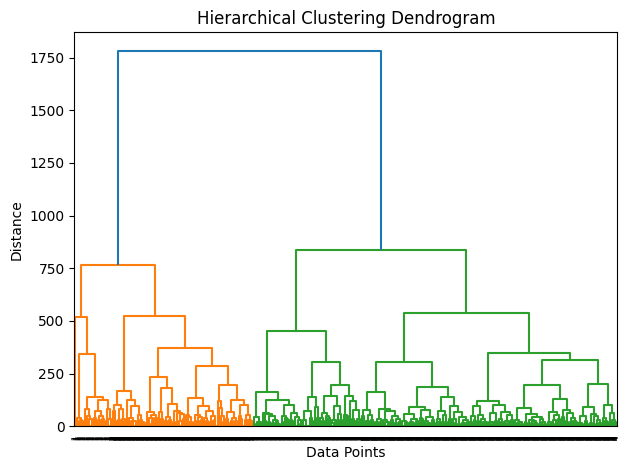

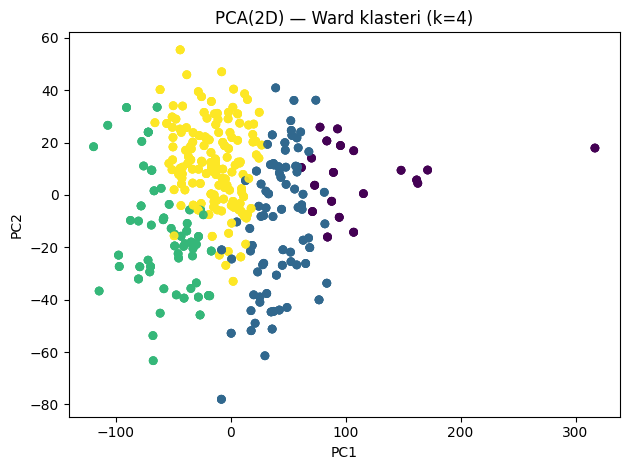

In [ ]:
X = df.drop(columns=['target'])
y = df['target']

X_scaled = RobustScaler().fit_transform(X)

Z = linkage(X, method="ward")
t=4
labels1 = fcluster(Z, t=t, criterion="maxclust")

plt.figure()
dendrogram(Z, labels=labels1)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

X2 = PCA(n_components=2, random_state=42).fit_transform(X)
plt.figure()
plt.scatter(X2[:, 0], X2[:, 1], c=labels1, s=28, alpha=0.9)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title(f"PCA(2D) — Ward klasteri (k={t})")
plt.tight_layout()
plt.show()


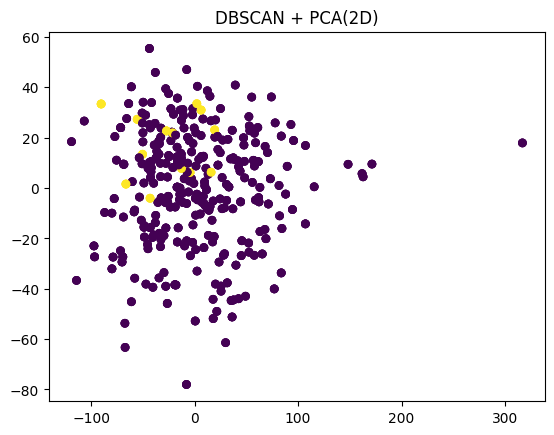

Broj klastera: 1 Udio šuma: 0.9551219512195122


In [ ]:
#DBSCAN
db = DBSCAN(eps=0.9, min_samples=10).fit(X_scaled)
labels2 = db.labels_

X2 = PCA(n_components=2, random_state=42).fit_transform(X)
plt.scatter(X2[:,0], X2[:,1], c=labels2, s=28); plt.title("DBSCAN + PCA(2D)"); plt.show()
print("Broj klastera:", len(set(labels2)-{-1}), "Udio šuma:", np.mean(labels2==-1))